<a href="https://colab.research.google.com/github/raja2005ar-design/Python/blob/main/Skin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install pandas numpy matplotlib seaborn scikit-learn joblib

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print(df.head())

Saving HAM10000_metadata.csv to HAM10000_metadata.csv
Dataset loaded successfully!
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nStatistical summary:")
display(df.describe(include="all"))

Shape: (10015, 7)

Columns:
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB

Missing values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Duplicate rows:
0

Statistical summary:


,lesion_id,image_id,dx,dx_type,age,sex,localization
count,10015,10015,10015,10015,9958.000000,10015,10015
unique,7470,10015,7,4,NaN,3,15
top,HAM_0000835,ISIC_0032258,nv,histo,NaN,male,back
freq,6,1,6705,5340,NaN,5406,2192
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN


In [ ]:


print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


In [ ]:
# ============================================
# 2. Separate features and target
# ============================================

target_column = "dx"

X = df.drop(columns=[target_column])
y = df[target_column]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10015, 6)
Target shape: (10015,)


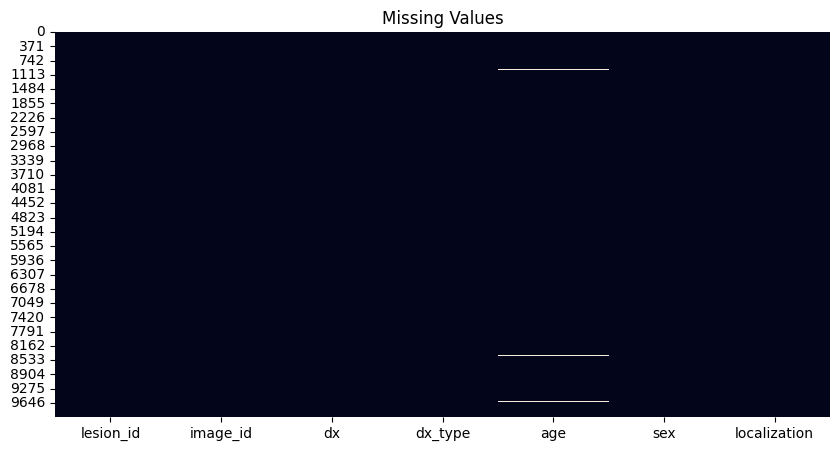

In [ ]:
# Missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

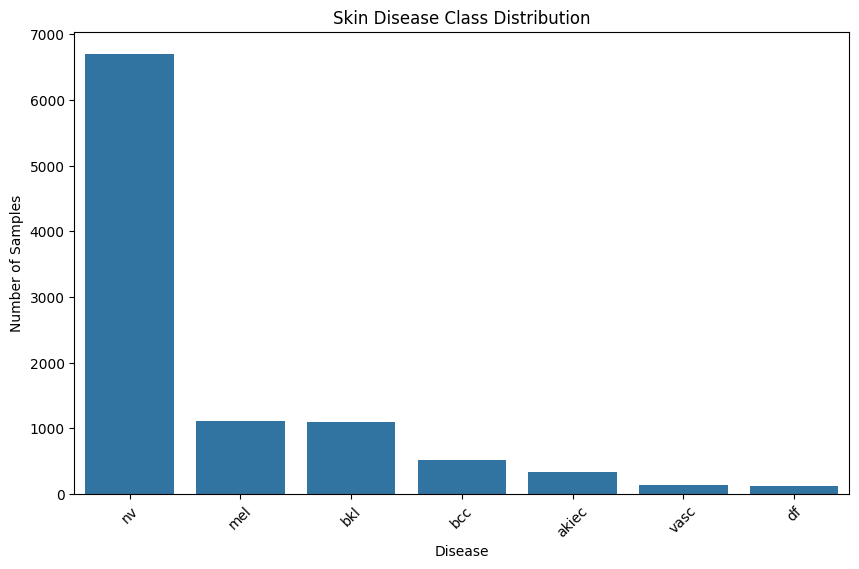

In [ ]:
# Replace 'Disease' with your actual target column
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='dx',
    order=df['dx'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Skin Disease Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Samples")
plt.show()

In [ ]:
# ============================================
# Remove ID columns
# ============================================

target_column = "dx"

# Columns that should NOT be used as ML features
columns_to_remove = [
    "lesion_id",
    "image_id"
]

# Remove only columns that actually exist
columns_to_remove = [
    col for col in columns_to_remove
    if col in df.columns
]

X = df.drop(columns=[target_column] + columns_to_remove)
y = df[target_column]

print("Features being used:")
print(X.columns.tolist())

Features being used:
['dx_type', 'age', 'sex', 'localization']


In [ ]:
# ============================================
# Handle missing values
# ============================================

numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numeric_columns:
    X[column] = X[column].fillna(X[column].median())

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns:
    X[column] = X[column].fillna(X[column].mode()[0])

In [ ]:
# ============================================
# Encode target
# ============================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

Classes:
['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [ ]:
# ============================================
# Convert categorical features
# ============================================

X = pd.get_dummies(X, drop_first=True)

print("Feature shape:", X.shape)
print("Remaining NaN values:", X.isnull().sum().sum())

Feature shape: (10015, 20)
Remaining NaN values: 0


In [ ]:
# ============================================
# Train-test split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# ============================================
# 7. Feature scaling
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")
print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)

Scaling completed successfully!
X_train: (8012, 20)
X_test: (2003, 20)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print(name)
    print("Accuracy:", accuracy)
    print("-" * 50)

Logistic Regression
Accuracy: 0.7014478282576135
--------------------------------------------------
Decision Tree
Accuracy: 0.7194208686969545
--------------------------------------------------
Random Forest
Accuracy: 0.7239141288067898
--------------------------------------------------
SVM
Accuracy: 0.7149276085871193
--------------------------------------------------
KNN
Accuracy: 0.692461308037943
--------------------------------------------------


In [ ]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("Model comparison:")
display(results_df)

Model comparison:


,Model,Accuracy
0,Random Forest,0.723914
1,Decision Tree,0.719421
2,SVM,0.714928
3,Logistic Regression,0.701448
4,KNN,0.692461


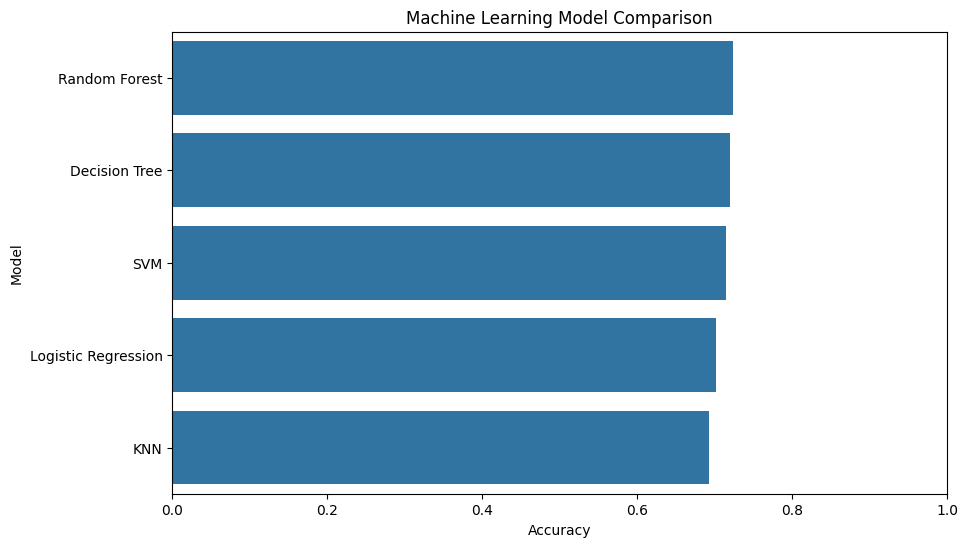

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.xlim(0, 1)
plt.title("Machine Learning Model Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

In [ ]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

best_model = models[best_model_name]

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

Best Model: Random Forest


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Model Evaluation")
print("================")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Model Evaluation
Accuracy : 0.7239141288067898
Precision: 0.6860883176267739
Recall   : 0.7239141288067898
F1 Score : 0.6991907931944548


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       akiec       0.33      0.14      0.20        65
         bcc       0.33      0.15      0.20       103
         bkl       0.48      0.46      0.47       220
          df       0.62      0.43      0.51        23
         mel       0.35      0.29      0.32       223
          nv       0.83      0.93      0.88      1341
        vasc       0.31      0.18      0.23        28

    accuracy                           0.72      2003
   macro avg       0.47      0.37      0.40      2003
weighted avg       0.69      0.72      0.70      2003



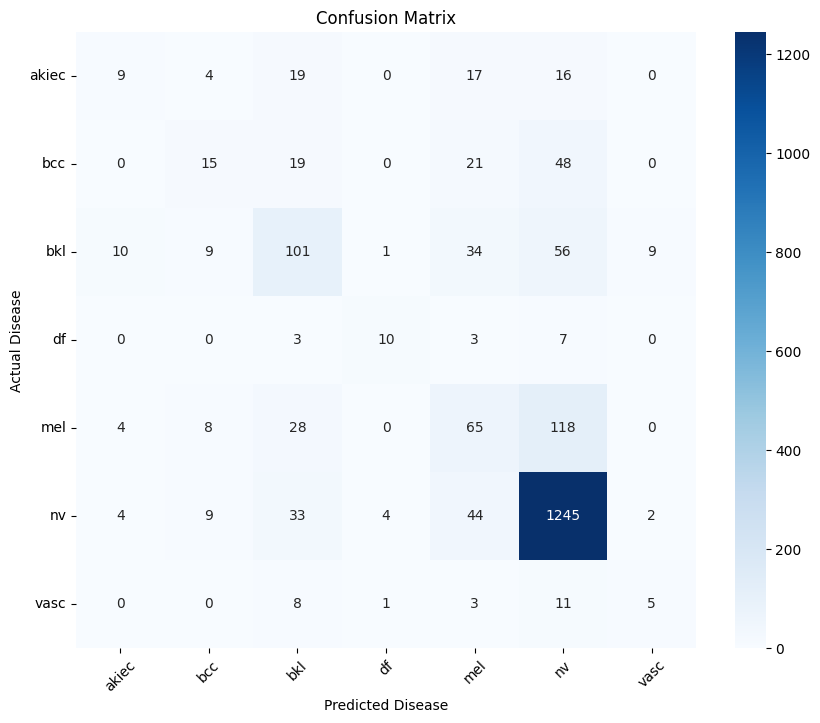

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:
joblib.dump(best_model, "skin_disease_model.pkl")
joblib.dump(scaler, "skin_disease_scaler.pkl")
joblib.dump(label_encoder, "skin_disease_label_encoder.pkl")

print("Model saved successfully!")

Model saved successfully!
